# Generate chaotic dynamics using the logistic map

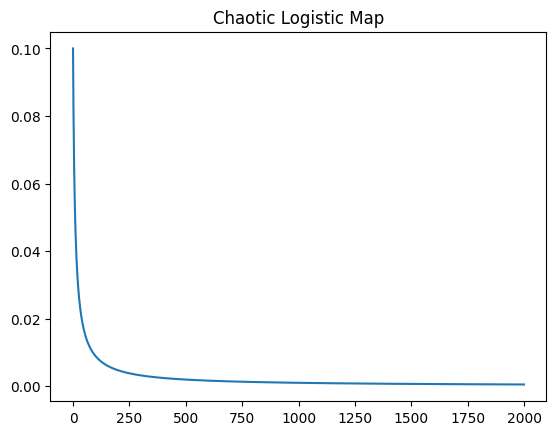

In [14]:
import numpy as np
import matplotlib.pyplot as plt

def generate_logistic(T=1000, r=2.5, x0=0.2):
    x = np.zeros(T)
    x[0] = x0
    for t in range(T-1):
        x[t+1] = r * x[t] * (1 - x[t])
    return x

data = generate_logistic(T=2000, r=1, x0=0.1)
plt.plot(data[:2000])
plt.title("Chaotic Logistic Map")
plt.show()

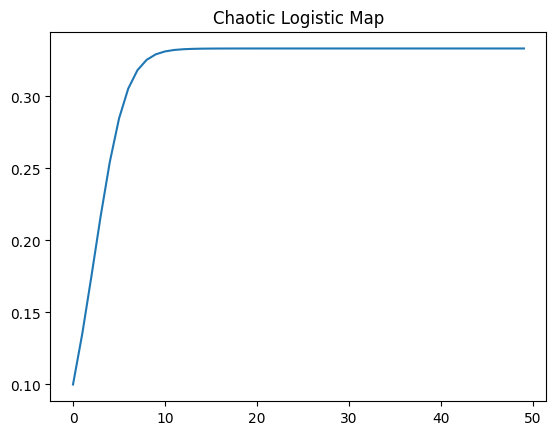

In [18]:
import numpy as np
import matplotlib.pyplot as plt

def generate_logistic(T=1000, r=2.5, x0=0.2):
    x = np.zeros(T)
    x[0] = x0
    for t in range(T-1):
        x[t+1] = r * x[t] * (1 - x[t])
    return x

data = generate_logistic(T=50, r=1.5, x0=0.1)
plt.plot(data[:50])
plt.title("Chaotic Logistic Map")
plt.show()

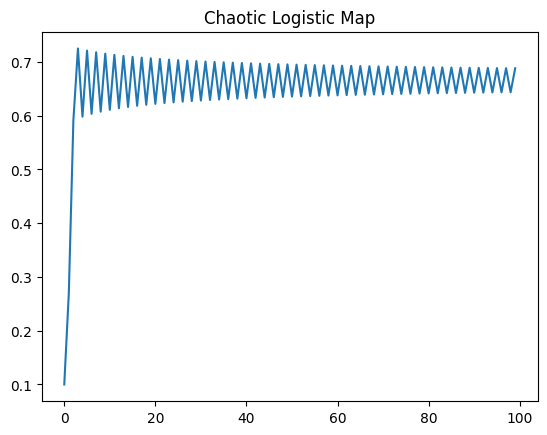

In [20]:
import numpy as np
import matplotlib.pyplot as plt

def generate_logistic(T=1000, r=2.5, x0=0.2):
    x = np.zeros(T)
    x[0] = x0
    for t in range(T-1):
        x[t+1] = r * x[t] * (1 - x[t])
    return x

data = generate_logistic(T=100, r=3, x0=0.1)
plt.plot(data[:100])
plt.title("Chaotic Logistic Map")
plt.show()

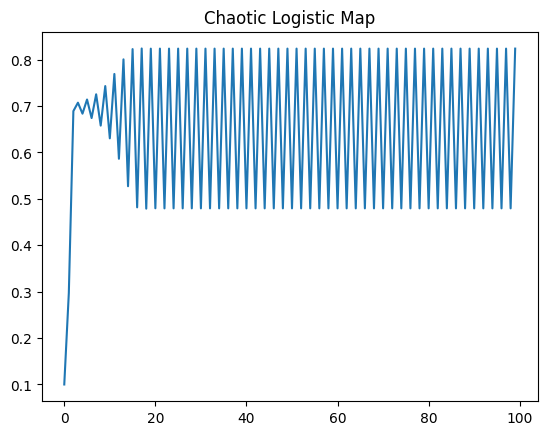

In [25]:
import numpy as np
import matplotlib.pyplot as plt

def generate_logistic(T=1000, r=2.5, x0=0.2):
    x = np.zeros(T)
    x[0] = x0
    for t in range(T-1):
        x[t+1] = r * x[t] * (1 - x[t])
    return x

data = generate_logistic(T=100, r=3.3, x0=0.1)
plt.plot(data[:100])
plt.title("Chaotic Logistic Map")
plt.show()

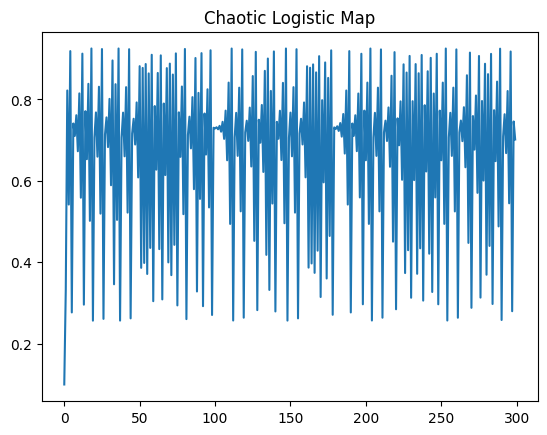

In [28]:
import numpy as np
import matplotlib.pyplot as plt

def generate_logistic(T=1000, r=2.5, x0=0.2):
    x = np.zeros(T)
    x[0] = x0
    for t in range(T-1):
        x[t+1] = r * x[t] * (1 - x[t])
    return x

data = generate_logistic(T=300, r=3.7, x0=0.1)
plt.plot(data[:300])
plt.title("Chaotic Logistic Map")
plt.show()

## 4-periodic points

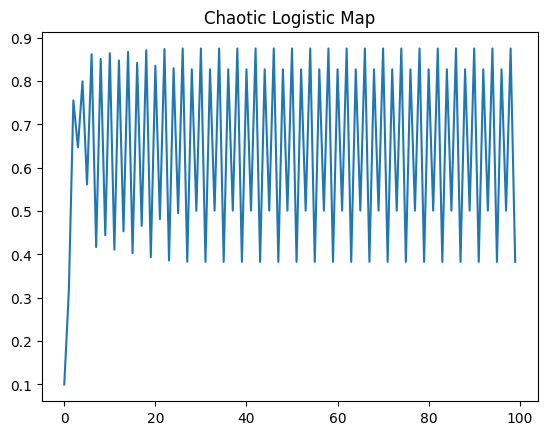

In [31]:

import numpy as np
import matplotlib.pyplot as plt

def generate_logistic(T=1000, r=2.5, x0=0.2):
    x = np.zeros(T)
    x[0] = x0
    for t in range(T-1):
        x[t+1] = r * x[t] * (1 - x[t])
    return x

data = generate_logistic(T=200, r=3.5, x0=0.1)
plt.plot(data[:100])
plt.title("Chaotic Logistic Map")
plt.show()

## Develop an RNN to predict the dynamics

Generating logistic map data...
Training samples: 7988, Validation samples: 1997
Sequence length: 15, Hidden size: 40
Learning rate: 0.005
Target mean: 0.4990, std: 0.3539

Epoch 05 | Train Loss: 0.012774 | Val Loss (norm): 0.005285 | Val MSE (orig): 0.000662 | Corr: 0.9976
Epoch 10 | Train Loss: 0.001905 | Val Loss (norm): 0.001959 | Val MSE (orig): 0.000245 | Corr: 0.9994
Epoch 15 | Train Loss: 0.001310 | Val Loss (norm): 0.001758 | Val MSE (orig): 0.000220 | Corr: 0.9994
Epoch 20 | Train Loss: 0.001062 | Val Loss (norm): 0.000910 | Val MSE (orig): 0.000114 | Corr: 0.9996
Epoch 25 | Train Loss: 0.000936 | Val Loss (norm): 0.000798 | Val MSE (orig): 0.000100 | Corr: 0.9997
Epoch 30 | Train Loss: 0.000849 | Val Loss (norm): 0.000753 | Val MSE (orig): 0.000094 | Corr: 0.9997
Epoch 35 | Train Loss: 0.000796 | Val Loss (norm): 0.000579 | Val MSE (orig): 0.000072 | Corr: 0.9997
Early stopping at epoch 37

Restored best model with validation loss: 0.000579

FINAL EVALUATION
Validation MSE: 

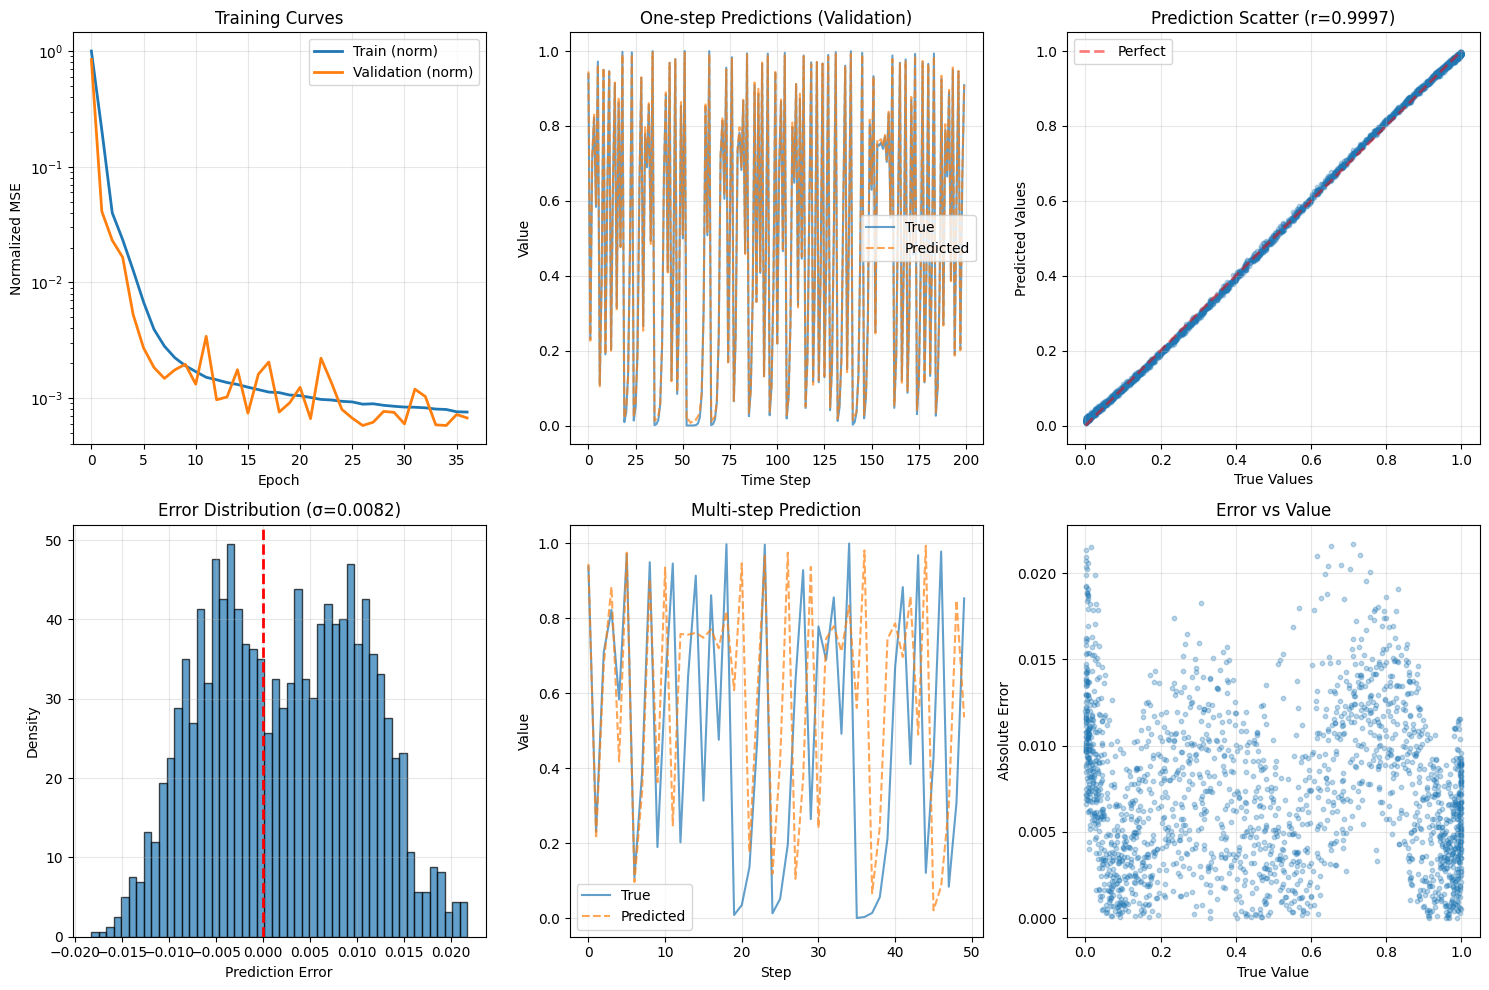


DETAILED STATISTICS
Best normalized validation loss: 0.000579
Final normalized validation loss: 0.000673
Final MSE (original scale): 0.000072
Final MAE (original scale): 0.007212
RMSE: 0.008513
Error Std: 0.008218
Error Range: [-0.018282, 0.021711]

VERIFICATION
Target range: [0.0000, 1.0000]
Prediction range: [0.0069, 0.9977]
Should be similar if denormalization worked!


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')

# =========================
# 1) Generate logistic map
# =========================
def generate_logistic(T=5000, r=4.0, x0=0.2, discard=1000):
    """Generate logistic map with multiple starting points for diversity"""
    x = np.zeros(T + discard, dtype=np.float64)
    x[0] = x0
    for t in range(T + discard - 1):
        x[t + 1] = r * x[t] * (1 - x[t])
    return x[discard:]

# =========================
# 2) Create sequences
# =========================
def create_sequences(series, seq_len=10, stride=1):
    """Create sequences with stride for more efficient data usage"""
    X, Y = [], []
    for i in range(0, len(series) - seq_len, stride):
        X.append(series[i:i + seq_len])
        Y.append(series[i + seq_len])
    return np.array(X, dtype=np.float64), np.array(Y, dtype=np.float64)

# =========================
# 3) Improved RNN
# =========================
class ImprovedRNN:
    def __init__(self, input_size=1, hidden_size=30, output_size=1, lr=0.01, seed=42):
        np.random.seed(seed)

        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.lr = lr

        # Xavier/Glorot initialization
        self.Wx = np.random.randn(hidden_size, input_size) * np.sqrt(2.0 / (input_size + hidden_size))
        self.Wh = np.random.randn(hidden_size, hidden_size) * np.sqrt(2.0 / (hidden_size + hidden_size))
        self.Why = np.random.randn(output_size, hidden_size) * np.sqrt(2.0 / (hidden_size + output_size))

        # Biases
        self.bh = np.zeros((hidden_size, 1))
        self.by = np.zeros((output_size, 1))

    def forward(self, seq):
        """Forward pass"""
        h = np.zeros((self.hidden_size, 1))
        
        hs = [h.copy()]
        xs = []
        
        for t in range(len(seq)):
            x_t = np.array([[seq[t]]])
            a_t = self.Wx @ x_t + self.Wh @ h + self.bh
            h = np.tanh(a_t)
            
            xs.append(x_t)
            hs.append(h.copy())
        
        y = self.Why @ h + self.by
        
        cache = {
            'xs': xs,
            'hs': hs,
            'seq_len': len(seq)
        }
        return y, cache

    def backward(self, cache, y, target, clip_value=1.0):
        """BPTT"""
        xs = cache['xs']
        hs = cache['hs']
        T = cache['seq_len']
        
        target = np.array([[float(target)]])
        dy = 2.0 * (y - target)
        
        dWhy = dy @ hs[-1].T
        dby = dy
        
        dWx = np.zeros_like(self.Wx)
        dWh = np.zeros_like(self.Wh)
        dbh = np.zeros_like(self.bh)
        
        dh_next = np.zeros((self.hidden_size, 1))
        
        for t in reversed(range(T)):
            if t == T - 1:
                dh = (self.Why.T @ dy) + dh_next
            else:
                dh = dh_next
            
            h_t = hs[t + 1]
            dtanh = (1 - h_t * h_t) * dh
            
            x_t = xs[t]
            h_prev = hs[t]
            
            dWx += dtanh @ x_t.T
            dWh += dtanh @ h_prev.T
            dbh += dtanh
            
            dh_next = self.Wh.T @ dtanh
        
        # Gradient clipping
        for grad in [dWx, dWh, dWhy, dbh, dby]:
            np.clip(grad, -clip_value, clip_value, out=grad)
        
        return dWx, dWh, dWhy, dbh, dby

    def update(self, gradients):
        """Update parameters"""
        dWx, dWh, dWhy, dbh, dby = gradients
        self.Wx -= self.lr * dWx
        self.Wh -= self.lr * dWh
        self.Why -= self.lr * dWhy
        self.bh -= self.lr * dbh
        self.by -= self.lr * dby

    def train_step(self, seq, target):
        """Single training step"""
        y, cache = self.forward(seq)
        gradients = self.backward(cache, y, target)
        self.update(gradients)
        loss = float((y - target) ** 2)
        return loss

    def predict(self, seq):
        """Make prediction"""
        y, _ = self.forward(seq)
        return float(y[0, 0])

# =========================
# 4) Training with proper denormalization
# =========================
class Normalizer:
    def __init__(self):
        self.mean = None
        self.std = None
    
    def fit(self, data):
        self.mean = np.mean(data)
        self.std = np.std(data) + 1e-8
        return self
    
    def normalize(self, data):
        return (data - self.mean) / self.std
    
    def denormalize(self, data):
        return data * self.std + self.mean

def train_rnn(
    series,
    seq_len=15,
    hidden_size=40,
    lr=0.005,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    patience=10
):
    """Train RNN with proper denormalization"""
    
    # Prepare data
    X, Y = create_sequences(series, seq_len=seq_len, stride=1)
    
    # Split data
    split = int(len(X) * (1 - validation_split))
    X_train, Y_train = X[:split], Y[:split]
    X_val, Y_val = X[split:], Y[split:]
    
    # Create normalizer and normalize targets
    normalizer = Normalizer()
    normalizer.fit(Y_train)
    Y_train_norm = normalizer.normalize(Y_train)
    Y_val_norm = normalizer.normalize(Y_val)
    
    # Initialize model
    model = ImprovedRNN(
        input_size=1,
        hidden_size=hidden_size,
        output_size=1,
        lr=lr
    )
    
    print(f"Training samples: {len(X_train)}, Validation samples: {len(X_val)}")
    print(f"Sequence length: {seq_len}, Hidden size: {hidden_size}")
    print(f"Learning rate: {lr}")
    print(f"Target mean: {normalizer.mean:.4f}, std: {normalizer.std:.4f}\n")
    
    # Training loop
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None
    
    for epoch in range(epochs):
        # Shuffle training data
        idx = np.random.permutation(len(X_train))
        X_train_shuffled = X_train[idx]
        Y_train_shuffled = Y_train_norm[idx]
        
        # Mini-batch training
        epoch_loss = 0
        n_batches = 0
        
        for i in range(0, len(X_train), batch_size):
            batch_X = X_train_shuffled[i:i+batch_size]
            batch_Y = Y_train_shuffled[i:i+batch_size]
            
            batch_loss = 0
            for j in range(len(batch_X)):
                loss = model.train_step(batch_X[j], batch_Y[j])
                batch_loss += loss
            
            epoch_loss += batch_loss / len(batch_X)
            n_batches += 1
        
        avg_train_loss = epoch_loss / n_batches
        train_losses.append(avg_train_loss)
        
        # Validation (on normalized scale for loss)
        val_loss_norm = 0
        predictions_norm = []
        
        for i in range(len(X_val)):
            pred_norm = model.predict(X_val[i])
            predictions_norm.append(pred_norm)
            val_loss_norm += (pred_norm - Y_val_norm[i]) ** 2
        
        avg_val_loss_norm = val_loss_norm / len(X_val)
        val_losses.append(avg_val_loss_norm)
        
        # Denormalize predictions for correlation calculation
        predictions = normalizer.denormalize(np.array(predictions_norm))
        
        # Calculate correlation
        if len(predictions) > 1:
            corr, _ = pearsonr(predictions.flatten(), Y_val.flatten())
        else:
            corr = 0
        
        # Early stopping check (on normalized loss)
        if avg_val_loss_norm < best_val_loss:
            best_val_loss = avg_val_loss_norm
            patience_counter = 0
            # Save best model state
            best_model_state = {
                'Wx': model.Wx.copy(),
                'Wh': model.Wh.copy(),
                'Why': model.Why.copy(),
                'bh': model.bh.copy(),
                'by': model.by.copy()
            }
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch + 1}")
                break
        
        if (epoch + 1) % 5 == 0:
            # Calculate MSE on original scale for reporting
            mse_original = np.mean((predictions - Y_val) ** 2)
            print(f"Epoch {epoch + 1:02d} | Train Loss: {avg_train_loss:.6f} | "
                  f"Val Loss (norm): {avg_val_loss_norm:.6f} | "
                  f"Val MSE (orig): {mse_original:.6f} | Corr: {corr:.4f}")
    
    # Restore best model
    if best_model_state:
        for key, value in best_model_state.items():
            setattr(model, key, value)
        print(f"\nRestored best model with validation loss: {best_val_loss:.6f}")
    
    return model, normalizer, (X_train, Y_train, X_val, Y_val), (train_losses, val_losses)

# =========================
# 5) Main execution
# =========================
if __name__ == "__main__":
    # Generate data
    print("Generating logistic map data...")
    series = generate_logistic(T=10000, r=4.0, x0=0.2)
    
    # Train model
    model, normalizer, datasets, losses = train_rnn(
        series=series,
        seq_len=15,
        hidden_size=40,
        lr=0.005,
        epochs=50,
        batch_size=64,
        validation_split=0.2,
        patience=10
    )
    
    (X_train, Y_train, X_val, Y_val) = datasets
    (train_losses, val_losses) = losses
    
    # Comprehensive evaluation
    print("\n" + "="*60)
    print("FINAL EVALUATION")
    print("="*60)
    
    # Get predictions on validation set
    val_preds_norm = []
    for i in range(len(X_val)):
        pred_norm = model.predict(X_val[i])
        val_preds_norm.append(pred_norm)
    
    val_preds = normalizer.denormalize(np.array(val_preds_norm))
    val_targets = Y_val
    
    # Calculate metrics
    mse = np.mean((val_preds - val_targets) ** 2)
    mae = np.mean(np.abs(val_preds - val_targets))
    corr, _ = pearsonr(val_preds.flatten(), val_targets.flatten())
    
    print(f"Validation MSE:  {mse:.6f}")
    print(f"Validation MAE:  {mae:.6f}")
    print(f"Correlation:     {corr:.6f}")
    
    # Visualization
    plt.figure(figsize=(15, 10))
    
    # Training curves
    plt.subplot(2, 3, 1)
    plt.plot(train_losses, label='Train (norm)', linewidth=2)
    plt.plot(val_losses, label='Validation (norm)', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Normalized MSE')
    plt.title('Training Curves')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.yscale('log')
    
    # One-step predictions
    plt.subplot(2, 3, 2)
    n_plot = min(200, len(val_preds))
    plt.plot(val_targets[:n_plot], label='True', alpha=0.7, linewidth=1.5)
    plt.plot(val_preds[:n_plot], label='Predicted', alpha=0.7, linewidth=1.5, linestyle='--')
    plt.xlabel('Time Step')
    plt.ylabel('Value')
    plt.title('One-step Predictions (Validation)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Scatter plot
    plt.subplot(2, 3, 3)
    plt.scatter(val_targets, val_preds, alpha=0.3, s=10)
    plt.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Perfect', alpha=0.5)
    plt.xlabel('True Values')
    plt.ylabel('Predicted Values')
    plt.title(f'Prediction Scatter (r={corr:.4f})')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Error distribution
    plt.subplot(2, 3, 4)
    errors = val_preds - val_targets
    plt.hist(errors, bins=50, edgecolor='black', alpha=0.7, density=True)
    plt.axvline(x=0, color='r', linestyle='--', linewidth=2)
    plt.xlabel('Prediction Error')
    plt.ylabel('Density')
    plt.title(f'Error Distribution (σ={np.std(errors):.4f})')
    plt.grid(True, alpha=0.3)
    
    # Multi-step prediction
    plt.subplot(2, 3, 5)
    steps = 50
    seed = X_val[0].copy()
    multi_preds = []
    multi_true = Y_val[:steps]
    
    for i in range(steps):
        pred_norm = model.predict(seed)
        pred = normalizer.denormalize(np.array([pred_norm]))[0]
        multi_preds.append(pred)
        seed = np.concatenate([seed[1:], [pred]])
    
    plt.plot(multi_true, label='True', alpha=0.7, linewidth=1.5)
    plt.plot(multi_preds, label='Predicted', alpha=0.7, linewidth=1.5, linestyle='--')
    plt.xlabel('Step')
    plt.ylabel('Value')
    plt.title('Multi-step Prediction')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Error vs value plot
    plt.subplot(2, 3, 6)
    plt.scatter(val_targets, np.abs(errors), alpha=0.3, s=10)
    plt.xlabel('True Value')
    plt.ylabel('Absolute Error')
    plt.title('Error vs Value')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed statistics
    print("\n" + "="*60)
    print("DETAILED STATISTICS")
    print("="*60)
    print(f"Best normalized validation loss: {min(val_losses):.6f}")
    print(f"Final normalized validation loss: {val_losses[-1]:.6f}")
    print(f"Final MSE (original scale): {mse:.6f}")
    print(f"Final MAE (original scale): {mae:.6f}")
    print(f"RMSE: {np.sqrt(mse):.6f}")
    print(f"Error Std: {np.std(errors):.6f}")
    print(f"Error Range: [{np.min(errors):.6f}, {np.max(errors):.6f}]")
    
    # Show denormalization worked
    print("\n" + "="*60)
    print("VERIFICATION")
    print("="*60)
    print(f"Target range: [{np.min(Y_val):.4f}, {np.max(Y_val):.4f}]")
    print(f"Prediction range: [{np.min(val_preds):.4f}, {np.max(val_preds):.4f}]")
    print(f"Should be similar if denormalization worked!")

Generating logistic map data...
Training samples: 7988, Validation samples: 1997
Sequence length: 15, Hidden size: 40
Learning rate: 0.005
Target mean: 0.4990, std: 0.3539

Epoch 05 | Train Loss: 0.012774 | Val Loss (norm): 0.005285 | Val MSE (orig): 0.000662 | Corr: 0.9976
Epoch 10 | Train Loss: 0.001905 | Val Loss (norm): 0.001959 | Val MSE (orig): 0.000245 | Corr: 0.9994
Epoch 15 | Train Loss: 0.001310 | Val Loss (norm): 0.001758 | Val MSE (orig): 0.000220 | Corr: 0.9994
Epoch 20 | Train Loss: 0.001062 | Val Loss (norm): 0.000910 | Val MSE (orig): 0.000114 | Corr: 0.9996
Epoch 25 | Train Loss: 0.000936 | Val Loss (norm): 0.000798 | Val MSE (orig): 0.000100 | Corr: 0.9997
Epoch 30 | Train Loss: 0.000849 | Val Loss (norm): 0.000753 | Val MSE (orig): 0.000094 | Corr: 0.9997
Epoch 35 | Train Loss: 0.000796 | Val Loss (norm): 0.000579 | Val MSE (orig): 0.000072 | Corr: 0.9997
Early stopping at epoch 37

Restored best model with validation loss: 0.000579

FINAL EVALUATION
Validation MSE: 

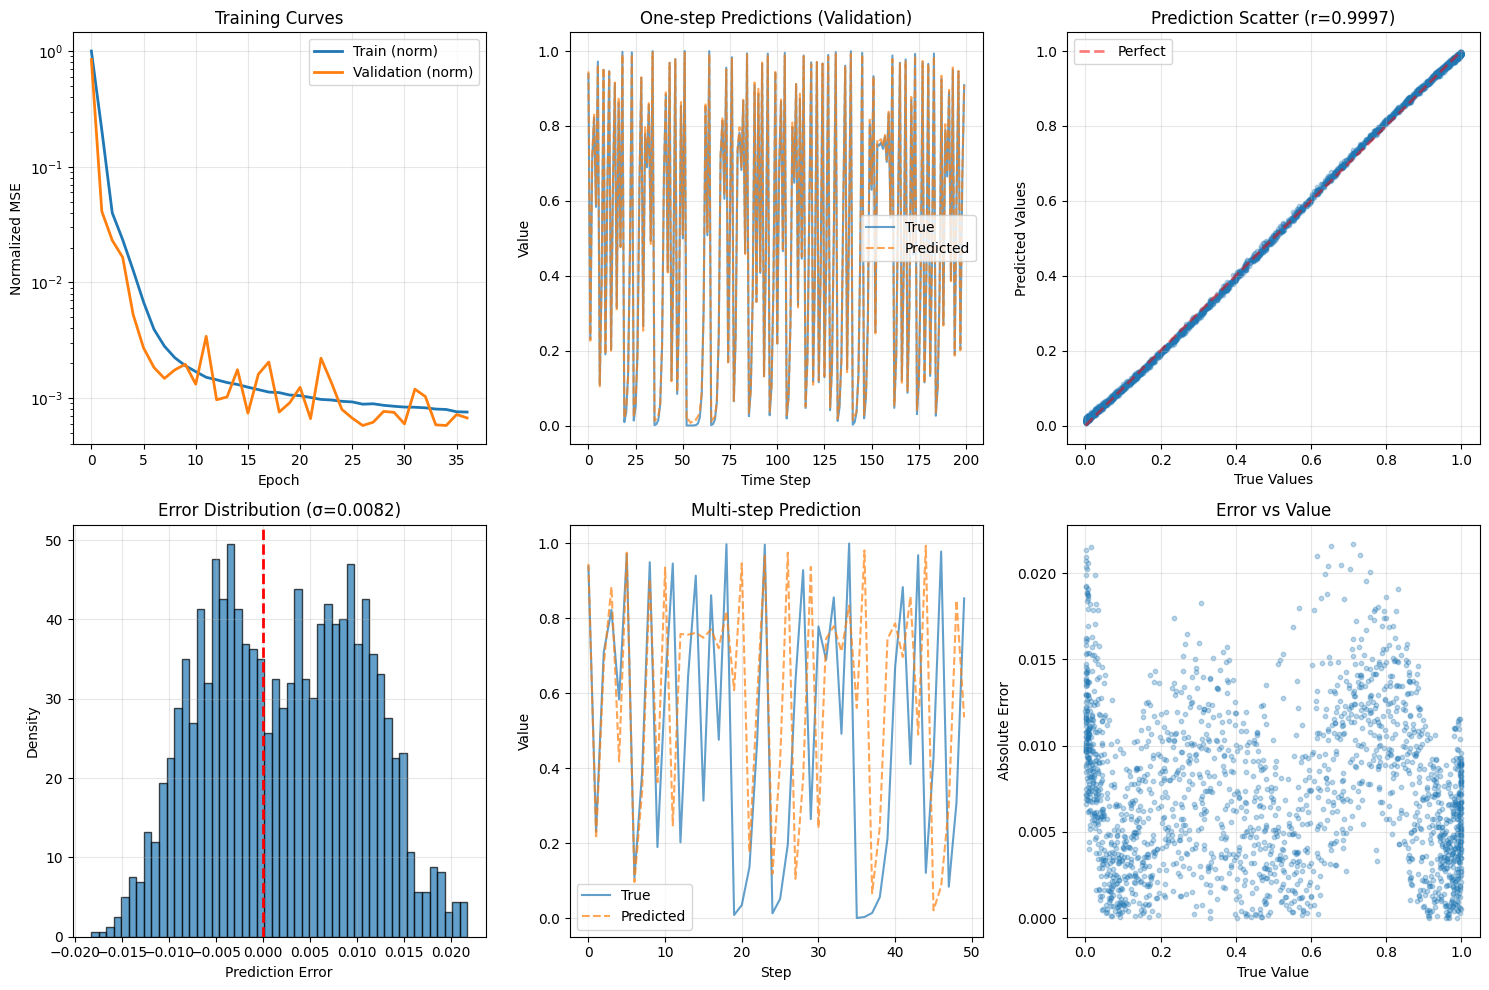


DETAILED STATISTICS
Best normalized validation loss: 0.000579
Final normalized validation loss: 0.000673
Final MSE (original scale): 0.000072
Final MAE (original scale): 0.007212
RMSE: 0.008513
Error Std: 0.008218
Error Range: [-0.018282, 0.021711]

VERIFICATION
Target range: [0.0000, 1.0000]
Prediction range: [0.0069, 0.9977]
Should be similar if denormalization worked!


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr # to calculate the correlation coefficient between RNN's prediction and actual ground-truth values
import warnings
warnings.filterwarnings('ignore')

# =========================
# 1) Generate logistic map
# =========================
def generate_logistic(T=5000, r=4.0, x0=0.2, discard=1000):
    """Generate logistic map and drop the first few data points"""
    x = np.zeros(T + discard, dtype=np.float64)
    x[0] = x0
    for t in range(T + discard - 1):
        x[t + 1] = r * x[t] * (1 - x[t])
    return x[discard:] # throw away the first 1000 points

# =========================
# 2) Create sequences (the features X and the labels Y)
# =========================
def create_sequences(series, seq_len=10, stride=1):
    """Create sequences with sliding a window of length (seq_len) across the data"""
    X, Y = [], []
    for i in range(0, len(series) - seq_len, stride):
        X.append(series[i:i + seq_len]) # the past information that the RNN will use to make a prediction
        Y.append(series[i + seq_len]) # the next single value is the "future", the correct answer that the RNN is trying to predict 
    return np.array(X, dtype=np.float64), np.array(Y, dtype=np.float64)

# =========================
# 3) Improved RNN
# =========================
class ImprovedRNN:
    def __init__(self, input_size=1, hidden_size=30, output_size=1, lr=0.01, seed=42):
        np.random.seed(seed)

        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.lr = lr

        # Xavier/Glorot initialization
        # The vanishing/exploding gradients lead to shrinking numbers after many layers
        # rescale the random numbers based on input and output nodes
        self.Wx = np.random.randn(hidden_size, input_size) * np.sqrt(2.0 / (input_size + hidden_size))
        self.Wh = np.random.randn(hidden_size, hidden_size) * np.sqrt(2.0 / (hidden_size + hidden_size))
        self.Why = np.random.randn(output_size, hidden_size) * np.sqrt(2.0 / (hidden_size + output_size))

        # Biases
        self.bh = np.zeros((hidden_size, 1))
        self.by = np.zeros((output_size, 1))

    def forward(self, seq):
        """Forward pass"""
        h = np.zeros((self.hidden_size, 1))
        
        hs = [h.copy()]
        xs = []
        
        for t in range(len(seq)):
            x_t = np.array([[seq[t]]])
            a_t = self.Wx @ x_t + self.Wh @ h + self.bh
            h = np.tanh(a_t)
            
            xs.append(x_t)
            hs.append(h.copy())
        
        y = self.Why @ h + self.by
        
        cache = {
            'xs': xs,
            'hs': hs,
            'seq_len': len(seq)
        }
        return y, cache

    def backward(self, cache, y, target, clip_value=1.0):
        """BPTT"""
        xs = cache['xs']
        hs = cache['hs']
        T = cache['seq_len']
        
        target = np.array([[float(target)]])
        dy = 2.0 * (y - target)
        
        dWhy = dy @ hs[-1].T
        dby = dy
        
        dWx = np.zeros_like(self.Wx)
        dWh = np.zeros_like(self.Wh)
        dbh = np.zeros_like(self.bh)
        
        dh_next = np.zeros((self.hidden_size, 1))
        
        for t in reversed(range(T)):
            if t == T - 1:
                dh = (self.Why.T @ dy) + dh_next
            else:
                dh = dh_next
            
            h_t = hs[t + 1]
            dtanh = (1 - h_t * h_t) * dh
            
            x_t = xs[t]
            h_prev = hs[t]
            
            dWx += dtanh @ x_t.T
            dWh += dtanh @ h_prev.T
            dbh += dtanh
            
            dh_next = self.Wh.T @ dtanh
        
        # Gradient clipping
        for grad in [dWx, dWh, dWhy, dbh, dby]:
            np.clip(grad, -clip_value, clip_value, out=grad)
        
        return dWx, dWh, dWhy, dbh, dby

    def update(self, gradients):
        """Update parameters"""
        dWx, dWh, dWhy, dbh, dby = gradients
        self.Wx -= self.lr * dWx
        self.Wh -= self.lr * dWh
        self.Why -= self.lr * dWhy
        self.bh -= self.lr * dbh
        self.by -= self.lr * dby

    def train_step(self, seq, target):
        """Single training step"""
        y, cache = self.forward(seq)
        gradients = self.backward(cache, y, target)
        self.update(gradients)
        loss = float((y - target) ** 2)
        return loss

    def predict(self, seq):
        """Make prediction"""
        y, _ = self.forward(seq)
        return float(y[0, 0])

# =========================
# 4) Training with proper denormalization
# =========================
class Normalizer:
    def __init__(self):
        self.mean = None
        self.std = None
    
    def fit(self, data):
        self.mean = np.mean(data)
        self.std = np.std(data) + 1e-8
        return self
    
    def normalize(self, data):
        # Performs the standardization
        return (data - self.mean) / self.std
    
    def denormalize(self, data):
        # The "reverse" of the standardization
        return data * self.std + self.mean

def train_rnn(
    series,
    seq_len=15,
    hidden_size=40,
    lr=0.005,
    epochs=50,
    batch_size=64,
    validation_split=0.2,  # 20% of the data will be used for validation
    patience=10 # if the performance does not improve for 10 consecutive epochs, stop and finish
):
    
    # Prepare data
    X, Y = create_sequences(series, seq_len=seq_len, stride=1)
    
    # Split data into training and validation datasets
    split = int(len(X) * (1 - validation_split))
    X_train, Y_train = X[:split], Y[:split]
    X_val, Y_val = X[split:], Y[split:]
    
    # Create normalizer and normalize targets
    normalizer = Normalizer()
    normalizer.fit(Y_train)  # compute the mean and std
    Y_train_norm = normalizer.normalize(Y_train)
    Y_val_norm = normalizer.normalize(Y_val)
    
    # Initialize model
    model = ImprovedRNN(
        input_size=1, # at each time step, the input is a number or scalar x[t]
        hidden_size=hidden_size, # the hidden state at each time step uses a vector of 40 numbers to act as 
                                # "memory" of previous time step information, h[t]=[h1, h2, .., h40]
                                # What happens if it is similar to or much smaller than seq_len?
        output_size=1, # at each time step the output is also a number or scalar o[t+1]
        lr=lr
    )
    
    print(f"Training samples: {len(X_train)}, Validation samples: {len(X_val)}")
    print(f"Sequence length: {seq_len}, Hidden size: {hidden_size}")
    print(f"Learning rate: {lr}")
    print(f"Target mean: {normalizer.mean:.4f}, std: {normalizer.std:.4f}\n")
    
    # Training loop
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None
    
    for epoch in range(epochs):
        # Shuffle training data
        idx = np.random.permutation(len(X_train))
        X_train_shuffled = X_train[idx]
        Y_train_shuffled = Y_train_norm[idx]
        
        # Mini-batch training
        epoch_loss = 0
        n_batches = 0
        
        for i in range(0, len(X_train), batch_size):
            batch_X = X_train_shuffled[i:i+batch_size]
            batch_Y = Y_train_shuffled[i:i+batch_size]
            
            batch_loss = 0
            for j in range(len(batch_X)):
                loss = model.train_step(batch_X[j], batch_Y[j])
                batch_loss += loss
            
            epoch_loss += batch_loss / len(batch_X)
            n_batches += 1
        
        avg_train_loss = epoch_loss / n_batches
        train_losses.append(avg_train_loss)
        
        # Validation (on normalized scale for loss)
        val_loss_norm = 0
        predictions_norm = []
        
        for i in range(len(X_val)):
            pred_norm = model.predict(X_val[i])
            predictions_norm.append(pred_norm)
            val_loss_norm += (pred_norm - Y_val_norm[i]) ** 2
        
        avg_val_loss_norm = val_loss_norm / len(X_val)
        val_losses.append(avg_val_loss_norm)
        
        # Denormalize predictions for correlation calculation
        predictions = normalizer.denormalize(np.array(predictions_norm))
        
        # Calculate correlation
        if len(predictions) > 1:
            corr, _ = pearsonr(predictions.flatten(), Y_val.flatten())
        else:
            corr = 0
        
        # Early stopping check (on normalized loss)
        if avg_val_loss_norm < best_val_loss:
            best_val_loss = avg_val_loss_norm
            patience_counter = 0
            # Save best model state
            best_model_state = {
                'Wx': model.Wx.copy(),
                'Wh': model.Wh.copy(),
                'Why': model.Why.copy(),
                'bh': model.bh.copy(),
                'by': model.by.copy()
            }
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch + 1}")
                break
        
        if (epoch + 1) % 5 == 0:
            # Calculate MSE on original scale for reporting
            mse_original = np.mean((predictions - Y_val) ** 2)
            print(f"Epoch {epoch + 1:02d} | Train Loss: {avg_train_loss:.6f} | "
                  f"Val Loss (norm): {avg_val_loss_norm:.6f} | "
                  f"Val MSE (orig): {mse_original:.6f} | Corr: {corr:.4f}")
    
    # Restore best model
    if best_model_state:
        for key, value in best_model_state.items():
            setattr(model, key, value)
        print(f"\nRestored best model with validation loss: {best_val_loss:.6f}")
    
    return model, normalizer, (X_train, Y_train, X_val, Y_val), (train_losses, val_losses)

# =========================
# 5) Main execution
# =========================
if __name__ == "__main__":
    # Generate data
    print("Generating logistic map data...")
    series = generate_logistic(T=10000, r=4.0, x0=0.2)
    
    # Train model
    model, normalizer, datasets, losses = train_rnn(
        series=series,
        seq_len=15,
        hidden_size=40,
        lr=0.005,
        epochs=50,
        batch_size=64,
        validation_split=0.2,
        patience=10
    )
    
    (X_train, Y_train, X_val, Y_val) = datasets
    (train_losses, val_losses) = losses
    
    # Comprehensive evaluation
    print("\n" + "="*60)
    print("FINAL EVALUATION")
    print("="*60)
    
    # Get predictions on validation set
    val_preds_norm = []
    for i in range(len(X_val)):
        pred_norm = model.predict(X_val[i])
        val_preds_norm.append(pred_norm)
    
    val_preds = normalizer.denormalize(np.array(val_preds_norm))
    val_targets = Y_val
    
    # Calculate metrics
    mse = np.mean((val_preds - val_targets) ** 2)
    mae = np.mean(np.abs(val_preds - val_targets))
    corr, _ = pearsonr(val_preds.flatten(), val_targets.flatten())
    
    print(f"Validation MSE:  {mse:.6f}")
    print(f"Validation MAE:  {mae:.6f}")
    print(f"Correlation:     {corr:.6f}")
    
    # Visualization
    plt.figure(figsize=(15, 10))
    
    # Training curves
    plt.subplot(2, 3, 1)
    plt.plot(train_losses, label='Train (norm)', linewidth=2)
    plt.plot(val_losses, label='Validation (norm)', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Normalized MSE')
    plt.title('Training Curves')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.yscale('log')
    
    # One-step predictions
    plt.subplot(2, 3, 2)
    n_plot = min(200, len(val_preds))
    plt.plot(val_targets[:n_plot], label='True', alpha=0.7, linewidth=1.5)
    plt.plot(val_preds[:n_plot], label='Predicted', alpha=0.7, linewidth=1.5, linestyle='--')
    plt.xlabel('Time Step')
    plt.ylabel('Value')
    plt.title('One-step Predictions (Validation)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Scatter plot
    plt.subplot(2, 3, 3)
    plt.scatter(val_targets, val_preds, alpha=0.3, s=10)
    plt.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Perfect', alpha=0.5)
    plt.xlabel('True Values')
    plt.ylabel('Predicted Values')
    plt.title(f'Prediction Scatter (r={corr:.4f})')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Error distribution
    plt.subplot(2, 3, 4)
    errors = val_preds - val_targets
    plt.hist(errors, bins=50, edgecolor='black', alpha=0.7, density=True)
    plt.axvline(x=0, color='r', linestyle='--', linewidth=2)
    plt.xlabel('Prediction Error')
    plt.ylabel('Density')
    plt.title(f'Error Distribution (σ={np.std(errors):.4f})')
    plt.grid(True, alpha=0.3)
    
    # Multi-step prediction
    plt.subplot(2, 3, 5)
    steps = 50
    seed = X_val[0].copy()
    multi_preds = []
    multi_true = Y_val[:steps]
    
    for i in range(steps):
        pred_norm = model.predict(seed)
        pred = normalizer.denormalize(np.array([pred_norm]))[0]
        multi_preds.append(pred)
        seed = np.concatenate([seed[1:], [pred]])
    
    plt.plot(multi_true, label='True', alpha=0.7, linewidth=1.5)
    plt.plot(multi_preds, label='Predicted', alpha=0.7, linewidth=1.5, linestyle='--')
    plt.xlabel('Step')
    plt.ylabel('Value')
    plt.title('Multi-step Prediction')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Error vs value plot
    plt.subplot(2, 3, 6)
    plt.scatter(val_targets, np.abs(errors), alpha=0.3, s=10)
    plt.xlabel('True Value')
    plt.ylabel('Absolute Error')
    plt.title('Error vs Value')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed statistics
    print("\n" + "="*60)
    print("DETAILED STATISTICS")
    print("="*60)
    print(f"Best normalized validation loss: {min(val_losses):.6f}")
    print(f"Final normalized validation loss: {val_losses[-1]:.6f}")
    print(f"Final MSE (original scale): {mse:.6f}")
    print(f"Final MAE (original scale): {mae:.6f}")
    print(f"RMSE: {np.sqrt(mse):.6f}")
    print(f"Error Std: {np.std(errors):.6f}")
    print(f"Error Range: [{np.min(errors):.6f}, {np.max(errors):.6f}]")
    
    # Show denormalization worked
    print("\n" + "="*60)
    print("VERIFICATION")
    print("="*60)
    print(f"Target range: [{np.min(Y_val):.4f}, {np.max(Y_val):.4f}]")
    print(f"Prediction range: [{np.min(val_preds):.4f}, {np.max(val_preds):.4f}]")
    print(f"Should be similar if denormalization worked!")